# Trabajo Práctico N°7 del TPS: PCA, K-means y EM

En este trabajo práctico se implementa un algoritmo de PCA condicional para aprender una curva representativa de un *manifold* 2D no lineal. La idea es combinar un algoritmo de clustering (K-Means y luego EM) con un PCA por cluster, de manera que cada cluster aproxime localmente una recta del manifold. Finalmente, se utiliza el error de reconstrucción del PCA como detector de anomalías.



Se importan las librerías que se utilizarán a lo largo del mismo.

In [39]:
import numpy as np
import matplotlib.pyplot as plt

## Inciso A: Creación del *dataset*



El objetivo de este inciso es generar datos sintéticos que simulen mediciones ruidosas de una curva en el plano. La curva subyacente (el manifold) es un triángulo formado por tres segmentos de recta, definido por la función $g(u)$ para $u \in [0, 1]$.

La curva subyacente se llama manifold: es una curva parametrizada $g(u)$ con $u \in [0,1]$, exactamente igual a las parametrizaciones de Análisis II. Con un solo parámetro $u$ se puede ubicar cualquier punto de la curva, aunque esa curva viva en $\mathbb{R}^2$. En este caso, $g(u)$ traza un triángulo, sube en diagonal, baja en diagonal, y vuelve horizontalmente al origen.

Para generar los datos se realiza una simulación de Monte Carlo con dos fuentes de aleatoriedad:
- $U_i \sim \mathcal{U}(0,1)$: elige un punto al azar a lo largo de la curva.
- $Z_i \sim \mathcal{N}(0, I)$: agrega ruido gaussiano en todas las direcciones, simulando error de medición.

El resultado es una nube de 200 puntos distribuidos cerca del triángulo. El objetivo de todo el TP es que los algoritmos recuperen ese triángulo a partir de los datos, sin saber de antemano que es un triángulo.

In [40]:
np.random.seed(42)

N = 200

# Sortear U_i ~ Uniform(0,1)
U = np.random.uniform(0, 1, N)

# Evaluar g(u) — tres tramos lineales
def g(u):
    x = np.where(u < 1/3,  1.5 * u,
        np.where(u < 2/3,  1.5 * u,
                            3 - 3 * u))
    y = np.where(u < 1/3,  3 * u,
        np.where(u < 2/3,  2 - 3 * u,
                            np.zeros_like(u)))
    return np.column_stack([x, y])

G = g(U)

# Ruido gaussiano estándar bivariado
Z = np.random.randn(N, 2)

X = G + 0.05 * Z

Se grafica el *scatter* y el *mainfold* en el mismo plano.

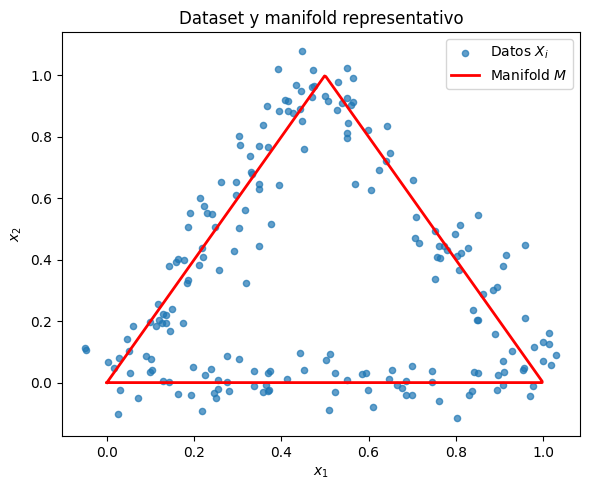

In [41]:
# Curva representativa del manifold (sin ruido)
u_curve = np.linspace(0, 1, 500)
M = g(u_curve)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], s=20, alpha=0.7, label='Datos $X_i$')
ax.plot(M[:, 0], M[:, 1], color='red', linewidth=2, label='Manifold $M$')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Dataset y manifold representativo')
ax.legend()
plt.tight_layout()
plt.show()

El gráfico muestra lo esperado: los 200 puntos forman tres nubes alargadas, una por cada lado del triángulo, y la curva roja pasa por el centro de cada nube. El ruido es pequeño pero visible. Hay dispersión perpendicular a cada lado, simulando correctamente el error de medición.

A partir de esta visualización se puede anticipar el comportamiento de los algoritmos de clustering:

- **K-Means:** agrupa por distancia al centroide, asumiendo clusters circulares (isótropos). Esto puede ser problemático acá porque los tres grupos son claramente alargados y orientados en distintas direcciones. En las esquinas del triángulo, donde se juntan puntos de dos lados distintos, K-Means puede cometer errores de asignación.
- **EM:** modela cada cluster con una Gaussiana completa (con covarianza), por lo que puede capturar la forma alargada de cada lado. Se espera que encuentre los tres grupos con mayor precisión.

## Inciso B: K-Means

Se implementa el algoritmo K-Means para clusterizar los datos. El primer paso es elegir $K$, la cantidad de clusters.

En la práctica, $K$ no se conoce de antemano. Las estrategias habituales son probar varios valores y usar métricas como el método del codo -**ver que onda eso**- (graficar la inercia en función de $K$ y buscar el punto donde la mejora se vuelve marginal) o el silhouette score (qué tan bien separado está cada punto de los clusters vecinos). Es análogo a elegir el orden de un filtro en telecomunicaciones: probás distintos órdenes y buscás el punto donde agregar más no mejora significativamente la respuesta.

En este caso se usa conocimiento del dominio: el manifold tiene 3 lados, por lo que $K = 3$ es la elección natural. En telecomunicaciones sería como saber de antemano cuántas fuentes de señal hay. Cada cluster debería capturar un lado del triángulo.

### Implementación

La clase `KMeans` se construye con la misma estructura que en el TP6: inicialización aleatoria de centroides, reasignación por distancia euclidiana y actualización iterativa hasta convergencia.

Los hiperparámetros son:
- `max_iter=300`: cota de seguridad para que el algoritmo no corra indefinidamente si no converge. En la práctica K-Means converge en pocas iteraciones para datasets chicos.
- `tol=1e-4`: el algoritmo se detiene cuando el desplazamiento de los centroides entre iteraciones es menor a este umbral. Es el criterio de convergencia.
- `random_state=0`: fija la semilla de inicialización para reproducibilidad. En general, se recomienda correr K-Means varias veces con distintas semillas y quedarse con la solución de menor inercia, ya que la inicialización aleatoria puede llevar a óptimos locales. En este caso, sin embargo, no vale la pena: como se anticipó en el análisis del inciso A, el problema no es la inicialización sino la suposición del modelo K-Means asume clusters esféricos, y los datos tienen forma alargada. Ninguna inicialización va a corregir ese desajuste estructural.

In [42]:
class KMeans:
    def __init__(self, k=3, max_iter=300, tol=1e-4, random_state=0):
        self.k = k
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.n_iter_ = None

    def fit(self, X):
        rng = np.random.default_rng(self.random_state)
        idx = rng.choice(len(X), self.k, replace=False)
        self.centroids = X[idx].astype(float).copy()

        for it in range(self.max_iter):
            labels = self._assign(X)

            new_centroids = np.array([
                X[labels == j].mean(axis=0) if np.any(labels == j)
                else self.centroids[j]
                for j in range(self.k)
            ])

            shift = np.max(np.linalg.norm(new_centroids - self.centroids, axis=1))
            self.centroids = new_centroids

            if shift < self.tol:
                self.n_iter_ = it + 1
                print(f'Convergió en {self.n_iter_} iteraciones (shift = {shift:.2e})')
                break
        else:
            self.n_iter_ = self.max_iter
            print(f'Máximo de iteraciones alcanzado ({self.max_iter})')

    def _assign(self, X):
        dists = np.linalg.norm(X[:, None, :] - self.centroids[None, :, :], axis=2)
        return np.argmin(dists, axis=1)

    def predict(self, X):
        return self._assign(X)

### Entrenamiento y visualización

Convergió en 5 iteraciones (shift = 0.00e+00)


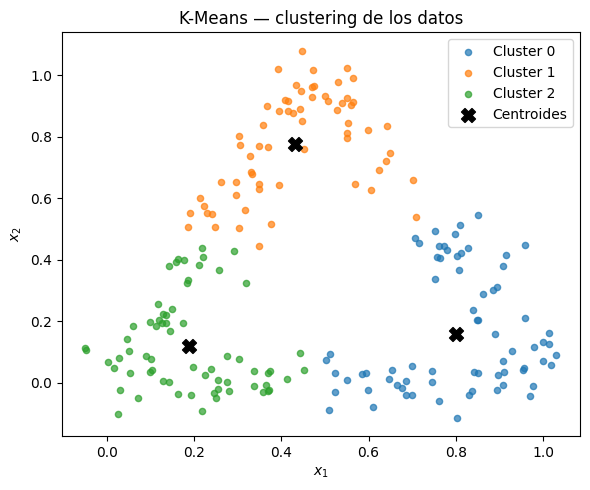

In [43]:
km = KMeans(k=3)
km.fit(X)
labels_km = km.predict(X)

colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots(figsize=(6, 5))
for j in range(km.k):
    mask = labels_km == j
    ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7, color=colors[j], label=f'Cluster {j}')
ax.scatter(km.centroids[:, 0], km.centroids[:, 1], s=100, marker='X', color='black', zorder=5, label='Centroides')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('K-Means — clustering de los datos')
ax.legend()
plt.tight_layout()
plt.show()

El algoritmo convergió en solo 5 iteraciones.

El gráfico valida la hipótesis planteada en el inciso A: los tres clusters recuperan aproximadamente los tres lados del triángulo, pero aparecen errores sistemáticos en las esquinas, donde puntos de un lado quedan asignados al cluster del lado adyacente. Esto es exactamente lo que se esperaba: K-Means asigna cada punto al centroide más cercano en distancia euclidiana, asumiendo implícitamente que los clusters son esféricos e isótropos. Los lados del triángulo son estructuras alargadas y orientadas, no círculos por lo tanto K-Means no es el modelo adecuado para esta geometría.

### ¿Es suficiente K-Means para esta tarea?

**No.** K-Means agrupa por proximidad al centroide sin considerar la orientación ni la forma de los clusters. En las esquinas del triángulo, un punto puede estar más cerca del centroide del lado adyacente que del centroide de su propio lado, simplemente porque los centroides quedan en el medio de cada lado. Esto genera errores de asignación sistemáticos en las zonas de transición entre segmentos.

Para capturar correctamente la geometría alargada de cada lado se necesita un modelo que modele también la covarianza de cada cluster, es decir, el algoritmo EM con mezclas de Gaussianas.

## Inciso C: Algoritmo Expectation-Maximization (EM)


K-Means no fue suficiente porque asume que todos los clusters son esféricos le fija la covarianza a la identidad y solo aprende el centro de cada grupo. Pero los datos tienen forma alargada: cada lado del triángulo es una nube orientada en una dirección, no un círculo. Ninguna inicialización ni ningún ajuste de K-Means puede corregir eso, porque el problema es estructural del modelo.

Para resolverlo se necesita un algoritmo que aprenda también la forma de cada cluster, no solo su centro. Ese algoritmo es **EM** (*Expectation-Maximization*), y el modelo subyacente es una mezcla de gaussianas.

### El modelo: mezcla de gaussianas

La idea es asumir que los datos fueron generados por $K$ fuentes gaussianas mezcladas. Cada fuente tiene:
- una **media** $\mu_k$: el centro del cluster,
- una **covarianza** $\Sigma_k$: la forma y orientación del cluster (libre, no fija),
- un **peso** $\pi_k$: qué fracción de los datos proviene de esa fuente.

A diferencia de K-Means, donde cada punto pertenece exactamente a un cluster, en el modelo de mezcla cada punto puede haber venido de cualquier fuente. Lo que se observa es el punto; de cuál fuente vino es una variable oculta que no se conoce.

### El problema del huevo y la gallina

Esto genera un dilema circular:
- Si se supiera de qué fuente vino cada punto, se podrían estimar fácilmente $\mu_k$, $\Sigma_k$ y $\pi_k$ como promedios ponderados.
- Si se conocieran $\mu_k$, $\Sigma_k$ y $\pi_k$, se podría calcular fácilmente la probabilidad de que cada punto venga de cada fuente.

EM resuelve este dilema alternando entre los dos pasos hasta converger.

### Expectation: ¿de dónde vino cada punto?

Dados los parámetros actuales, se calcula para cada punto $x_i$ la responsabilidad $r_{ik}$: qué tan probable es que haya venido de la fuente $k$. Esto es simplemente la regla de Bayes:

$$r_{ik} = \frac{\pi_k \, \mathcal{N}(x_i \mid \mu_k, \Sigma_k)}{\sum_{j=1}^{K} \pi_j \, \mathcal{N}(x_i \mid \mu_j, \Sigma_j)}$$

El numerador es la densidad de la gaussiana $k$ evaluada en $x_i$, pesada por la probabilidad a priori $\pi_k$ de esa fuente. El denominador normaliza para que las responsabilidades sumen 1. Un punto en la frontera entre dos clusters puede tener $r_{i1} = 0.6$ y $r_{i2} = 0.4$, por lo que pertenece parcialmente a ambos. Esto es lo que distingue a EM de K-Means: la asignación es blanda, no dura.

### Maximization: ¿cómo quedan los parámetros?

Dados los $r_{ik}$, se actualizan los parámetros como promedios ponderados donde el peso de cada punto en el cluster $k$ es su responsabilidad $r_{ik}$:

$$\mu_k = \frac{\sum_i r_{ik} \, x_i}{\sum_i r_{ik}}, \qquad \Sigma_k = \frac{\sum_i r_{ik} \, (x_i - \mu_k)(x_i - \mu_k)^T}{\sum_i r_{ik}}, \qquad \pi_k = \frac{\sum_i r_{ik}}{N}$$

La media es el centroide ponderado. La covarianza es la dispersión ponderada alrededor de ese centroide, si los puntos con alto $r_{ik}$ están distribuidos a lo largo de una recta, $\Sigma_k$ se estira en esa dirección. Los pesos $\pi_k$ reflejan cuántos puntos "pertenecen" a cada fuente.

### La convergencia

EM garantiza que la log-verosimilitud $\mathcal{L} = \sum_i \log p(x_i)$ nunca decrece entre iteraciones. Intuitivamente, esto mide qué tan bien el modelo explica los datos observados: una gaussiana estirada en la dirección de una nube alargada tiene mayor densidad sobre esos puntos que una esférica, por lo que contribuye más a $\mathcal{L}$. El algoritmo se detiene cuando la mejora entre iteraciones cae por debajo de un umbral `tol`.

### Comparación con K-Means

| | K-Means | EM |
|---|---|---|
| Forma del cluster | esférica (fija) | libre (aprende $\Sigma_k$) |
| Asignación de puntos | dura (un cluster) | blanda ($r_{ik} \in [0,1]$) |
| Parámetros | solo $\mu_k$ | $\mu_k$, $\Sigma_k$, $\pi_k$ |
| Criterio de convergencia | desplazamiento de centroides | log-verosimilitud |

K-Means es de hecho, a muy grandes rasgos y bajo ciertas condiciones, un caso límite de EM: si se fija $\Sigma_k = I$ para todo $k$ y se llevan las responsabilidades a 0 o 1 (asignación dura), se recupera exactamente el algoritmo K-Means.

### Implementación


Los hiperparámetros `max_iter=100` y `tol=1e-4` se mantienen consistentes con los TPs anteriores. Se redujo `max_iter` a 100 respecto del K-Means (que usó 300) porque cada iteración de EM es más costosa, implica calcular densidades gaussianas y actualizar covarianzas, y en la práctica el algoritmo converge bastante antes de ese límite.

La clase sigue la estructura teórica descripta: `fit` alterna el paso de Expectation (delegado a `predict_proba`, que computa las responsabilidades $r_{ik}$ vía regla de Bayes) y el paso de Maximization (actualización de $\mu_k$, $\Sigma_k$ y $\pi_k$ como promedios ponderados). El método auxiliar `_gauss` evalúa la densidad gaussiana multivariada de forma vectorizada usando `einsum`.

In [44]:
class EM:
    def __init__(self, k=3, max_iter=100, tol=1e-4, random_state=0):
        self.k = k
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.pi = None      # pesos (K,)
        self.mu = None      # medias (K, d)
        self.sigma = None   # covarianzas (K, d, d)
        self.n_iter_ = None

    def _gauss(self, X, k):
        d = X.shape[1]
        diff = X - self.mu[k]
        inv_sigma = np.linalg.inv(self.sigma[k])
        det_sigma = np.linalg.det(self.sigma[k])
        norm = 1 / ((2 * np.pi) ** (d / 2) * np.sqrt(det_sigma))
        exp_term = np.exp(-0.5 * np.einsum('ni,ij,nj->n', diff, inv_sigma, diff))
        return norm * exp_term

    def fit(self, X, init_mu=None):
        N, d = X.shape
        rng = np.random.default_rng(self.random_state)

        # Inicialización: init_mu explícita o muestras al azar
        if init_mu is not None:
            self.mu = np.array(init_mu, dtype=float).copy()
        else:
            idx = rng.choice(N, self.k, replace=False)
            self.mu = X[idx].astype(float).copy()
        self.pi = np.ones(self.k) / self.k
        self.sigma = np.array([np.eye(d) for _ in range(self.k)])

        log_lik_prev = -np.inf

        for it in range(self.max_iter):
            # E-step
            R = self.predict_proba(X)   # (N, K)

            # M-step
            Nk = R.sum(axis=0)          # (K,)
            self.pi = Nk / N
            self.mu = (R.T @ X) / Nk[:, None]
            for k in range(self.k):
                diff = X - self.mu[k]
                self.sigma[k] = (R[:, k, None] * diff).T @ diff / Nk[k]

            # Criterio de convergencia: log-verosimilitud
            log_lik = np.sum(np.log(
                sum(self.pi[k] * self._gauss(X, k) for k in range(self.k)) + 1e-300
            ))

            if abs(log_lik - log_lik_prev) < self.tol:
                self.n_iter_ = it + 1
                print(f'Convergió en {self.n_iter_} iteraciones (Δlog-lik = {abs(log_lik - log_lik_prev):.2e})')
                break
            log_lik_prev = log_lik
        else:
            self.n_iter_ = self.max_iter
            print(f'Máximo de iteraciones alcanzado ({self.max_iter})')

    def predict_proba(self, X):
        R = np.column_stack([self.pi[k] * self._gauss(X, k) for k in range(self.k)])
        R /= R.sum(axis=1, keepdims=True)
        return R

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

### Entrenamiento y visualización

Se entrena EM con $K=3$ y semilla 0. La etiqueta final de cada punto es el cluster de mayor responsabilidad (`predict` devuelve el argmax de $r_{ik}$). Se espera que los tres clusters queden alineados con los tres lados del triángulo, capturando su forma alargada en lugar de asignar puntos por simple cercanía al centroide.

Convergió en 34 iteraciones (Δlog-lik = 7.21e-05)


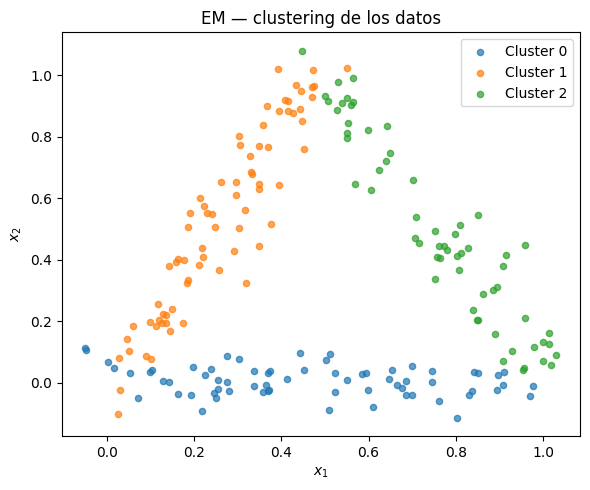

In [45]:
em = EM(k=3)
em.fit(X)
labels_em = em.predict(X)

colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots(figsize=(6, 5))
for j in range(em.k):
    mask = labels_em == j
    ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7, color=colors[j], label=f'Cluster {j}')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('EM — clustering de los datos')
ax.legend()
plt.tight_layout()
plt.show()

El resultado es notablemente mejor que K-Means. Los tres clusters quedan perfectamente alineados con los tres lados del triángulo: el azul captura la base horizontal, el naranja el lado izquierdo ascendente, y el verde el lado derecho descendente. No se observan errores de asignación en las esquinas, que era el punto débil de K-Means.

Esto confirma el argumento teórico: al aprender $\Sigma_k$ libremente, EM ajusta una gaussiana alargada en la dirección de cada lado, por lo que los puntos en las esquinas quedan correctamente asignados al cluster cuya covarianza está orientada hacia ellos, y no al que tiene el centroide más cercano.

### Fronteras de decisión

Para visualizar cómo EM divide el espacio, se evalúa `predict` sobre una grilla densa y se grafica la región asignada a cada cluster. Las fronteras de decisión de EM son curvas cuádricas (en general hipérbolas o parábolas), porque resultan de igualar las densidades gaussianas de dos clusters: cuando las covarianzas son distintas, esa igualdad da lugar a una ecuación cuadrática en $x$. Esto contrasta con K-Means, cuyas fronteras son siempre rectas.

La razón es geométrica: K-Means asigna cada punto al centroide más cercano, así que la frontera entre dos clusters $j$ y $k$ es el lugar donde $\|x - \mu_j\|^2 = \|x - \mu_k\|^2$. Al expandir esa igualdad, el término $\|x\|^2$ se cancela en ambos lados y queda una ecuación lineal en $x$:

$$2(\mu_k - \mu_j)^T x = \|\mu_k\|^2 - \|\mu_j\|^2$$

Eso es un hiperplano en 2D, la mediatriz del segmento que une los dos centroides. En EM, en cambio, la densidad gaussiana tiene $\Sigma_k^{-1}$ dentro del exponente: si las covarianzas son iguales se cancela y las fronteras también son lineales (ese es el caso LDA), pero si son distintas el término cuadrático en $x$ no desaparece y la frontera se curva.

La forma de estas fronteras también recuerda a las curvas de nivel del SVM con kernel RBF, pero el origen es distinto. En SVM las fronteras curvas vienen de un mapeo implícito a un espacio de alta dimensión, la curvatura la introduce el kernel. Acá no hay kernel: la curvatura emerge directamente de la geometría gaussiana con covarianzas distintas.

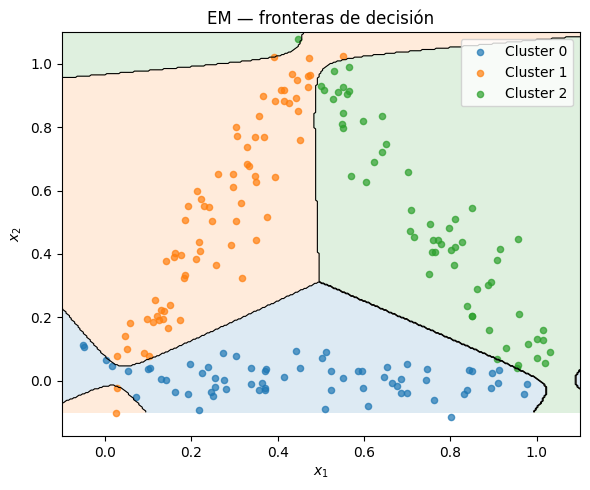

In [46]:
xx, yy = np.meshgrid(np.linspace(-0.1, 1.1, 300), np.linspace(-0.1, 1.1, 300))
grid = np.column_stack([xx.ravel(), yy.ravel()])
Z = em.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5, 2.5], alpha=0.15, colors=colors)
ax.contour(xx, yy, Z, levels=[-0.5, 0.5, 1.5, 2.5], colors='k', linewidths=0.8)
for j in range(em.k):
    mask = labels_em == j
    ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7, color=colors[j], label=f'Cluster {j}')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('EM — fronteras de decisión')
ax.legend()
plt.tight_layout()
plt.show()

El gráfico confirma todo lo que se anticipó. Las tres regiones están correctamente orientadas: azul cubre la base horizontal, naranja el lado izquierdo, verde el lado derecho. Las fronteras son curvas, se ve especialmente en la esquina inferior izquierda, donde la frontera entre naranja y azul describe una curva pronunciada en lugar de una recta, y en la esquina superior donde se juntan los tres clusters.

Esa curvatura en las esquinas es exactamente lo que permite a EM hacer lo que K-Means no podía: en las esquinas del triángulo, donde dos lados se encuentran, K-Means trazaría una recta que inevitablemente asignaría mal algunos puntos. EM, en cambio, curva la frontera para que siga la forma de las gaussianas aprendidas, capturando correctamente la transición entre un lado y el otro.

### Sensibilidad a la inicialización



#### Experimento 1: distintas semillas

Se corre EM 8 veces con distintas semillas para ver si la inicialización aleatoria afecta el resultado final.

Semilla 0: Convergió en 34 iteraciones (Δlog-lik = 7.21e-05)
Semilla 1: Convergió en 29 iteraciones (Δlog-lik = 5.27e-05)
Semilla 2: Convergió en 33 iteraciones (Δlog-lik = 5.77e-05)
Semilla 3: Convergió en 27 iteraciones (Δlog-lik = 5.54e-05)
Semilla 4: Convergió en 28 iteraciones (Δlog-lik = 6.55e-05)
Semilla 5: Convergió en 31 iteraciones (Δlog-lik = 4.06e-05)
Semilla 6: Convergió en 29 iteraciones (Δlog-lik = 6.70e-05)
Semilla 7: Convergió en 29 iteraciones (Δlog-lik = 7.72e-05)


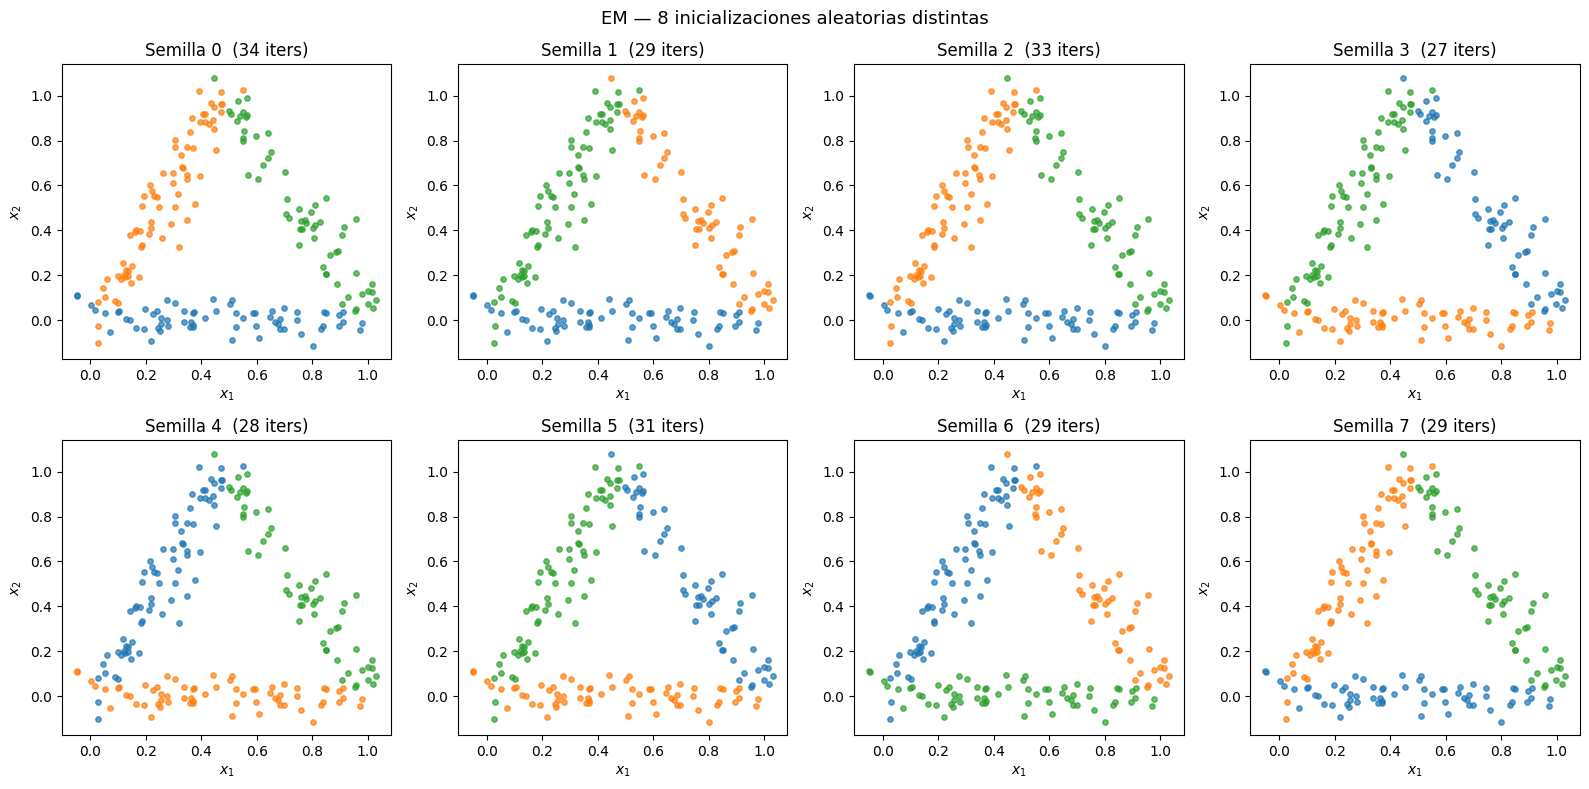

In [47]:
n_runs = 8
seeds = range(n_runs)
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, seed in enumerate(seeds):
    em_i = EM(k=3, random_state=seed)
    print(f'Semilla {seed}:', end=' ')
    em_i.fit(X)
    labels_i = em_i.predict(X)

    ax = axes[i]
    for j in range(em_i.k):
        mask = labels_i == j
        ax.scatter(X[mask, 0], X[mask, 1], s=15, alpha=0.7, color=colors[j])
    ax.set_title(f'Semilla {seed}  ({em_i.n_iter_} iters)')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

plt.suptitle('EM — 8 inicializaciones aleatorias distintas', fontsize=13)
plt.tight_layout()
plt.show()

Las 8 inicializaciones convergen al mismo resultado. Esto muestra que en este dataset la inicialización aleatoria de los centroides es genuinamente robusta: no importa de dónde arranquen los $\mu_k$, EM siempre encuentra la misma solución.

La razón es que los tres lados del triángulo están bien separados respecto al ruido ($\sigma = 0.05$). Cuando los centroides caen al azar en los datos, incluso si dos o tres quedan en el mismo lado, el paso de Expectation distribuye las responsabilidades de forma que en pocas iteraciones los centroides se repelen y cada uno migra hacia un lado distinto. La gran separación entre los grupos hace que esa migración sea estable y no quede atrapada a mitad de camino.

Dicho esto, la robustez no está garantizada en general, depende de la geometría del problema. A continuación se prueban dos casos de inicialización explícita para entender mejor los límites: uno favorable (los centroides de K-Means, que ya están bien ubicados) y uno adverso (tres puntos casi superpuestos cerca del vértice).

#### Experimento 2: inicialización con los centroides de K-Means

Una pregunta natural es qué pasa si en lugar de inicializar aleatoriamente, se le pasan a EM los centroides que encontró K-Means. En principio, K-Means ya ubicó un centroide por lado (con los errores de asignación en las esquinas que se documentaron), así que EM debería partir de una posición razonable. La pregunta es si eso lo lleva al mismo resultado o lo atrapa en un óptimo local distinto, y si converge más rápido al partir de ahí.

Convergió en 38 iteraciones (Δlog-lik = 5.21e-05)


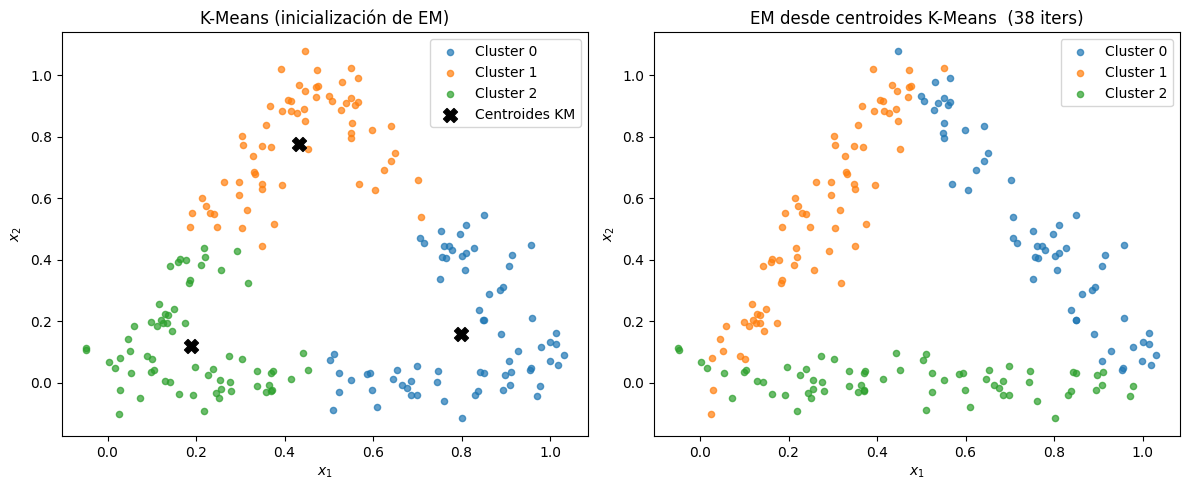

In [48]:
em_km_init = EM(k=3)
em_km_init.fit(X, init_mu=km.centroids)
labels_km_init = em_km_init.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Resultado K-Means (punto de partida)
ax = axes[0]
for j in range(km.k):
    mask = labels_km == j
    ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7, color=colors[j], label=f'Cluster {j}')
ax.scatter(km.centroids[:, 0], km.centroids[:, 1], s=100, marker='X', color='black', zorder=5, label='Centroides KM')
ax.set_title('K-Means (inicialización de EM)')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.legend()

# EM inicializado con centroides de K-Means
ax = axes[1]
for j in range(em_km_init.k):
    mask = labels_km_init == j
    ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7, color=colors[j], label=f'Cluster {j}')
ax.set_title(f'EM desde centroides K-Means  ({em_km_init.n_iter_} iters)')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.legend()

plt.tight_layout()
plt.show()

El resultado geométrico es idéntico al EM con inicialización aleatoria, misma partición de los tres lados, misma calidad de fronteras. Sin embargo, converge en más iteraciones que la mayoría de las semillas aleatorias (~38 vs. 27–34). Eso parece contraintuitivo pero tiene una explicación directa: K-Means dejó las esquinas mal asignadas (puntos donde dos lados se tocan), y esas asignaciones duras se traducen en centroides que están corridos respecto al centro real de cada segmento. En el paso de Expectation del primer ciclo, las responsabilidades suaves de EM ven esa imprecisión y comienzan a redistribuir puntos, lo que mueve los centroides más que si hubieran arrancado desde un punto aleatorio bien posicionado. EM tiene que "deshacer" primero el sesgo heredado de K-Means antes de converger.

El experimento confirma que usar K-Means como warm-start no garantiza acelerar EM, y que en este dataset la inicialización tiene poco peso: la geometría fuertemente separada permite convergencia robusta desde casi cualquier punto de partida.

#### Experimento 3: inicialización con 3 puntos consecutivos (caso adverso)

El peor caso imaginable para la inicialización es arrancar con los tres centroides casi en el mismo lugar. Para probarlo, se toman 3 puntos consecutivos del dataset que caigan cerca del vértice superior del triángulo, una zona donde los tres lados se juntan. Los tres centroides iniciales quedan así casi superpuestos, lo más lejos posible de la configuración ideal.

Convergió en 40 iteraciones (Δlog-lik = 5.94e-05)


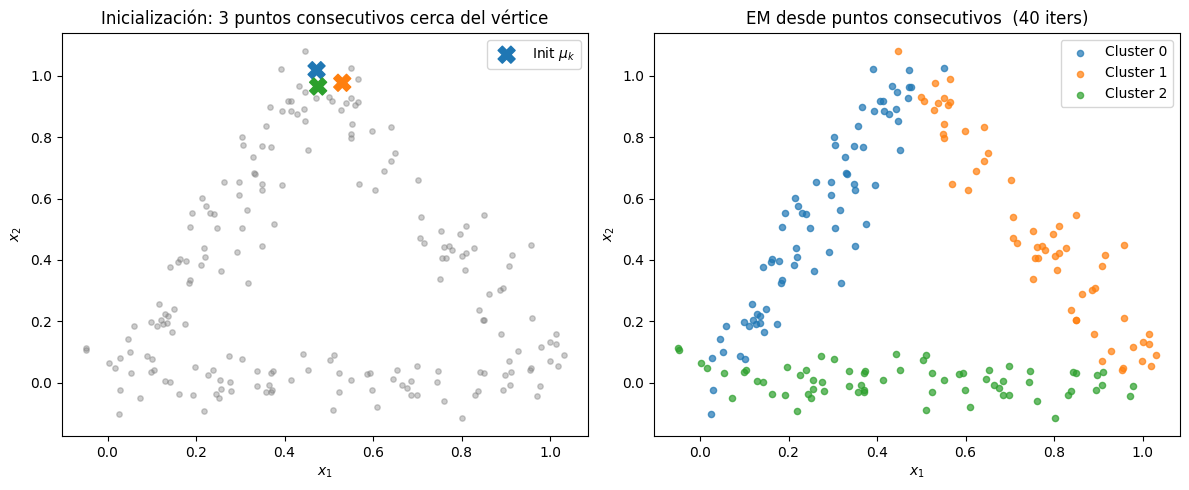

In [49]:
# Buscar puntos cerca del vértice superior (x1 ~ 0.5, x2 ~ 1.0)
apex_region = np.argsort(np.linalg.norm(X - np.array([0.5, 1.0]), axis=1))
init_consecutive = X[apex_region[:3]]

em_consec = EM(k=3)
em_consec.fit(X, init_mu=init_consecutive)
labels_consec = em_consec.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Mostrar la inicialización
ax = axes[0]
ax.scatter(X[:, 0], X[:, 1], s=15, alpha=0.4, color='gray')
ax.scatter(init_consecutive[:, 0], init_consecutive[:, 1], s=150, marker='X',
           color=['tab:blue', 'tab:orange', 'tab:green'], zorder=5, label='Init $\\mu_k$')
ax.set_title('Inicialización: 3 puntos consecutivos cerca del vértice')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.legend()

# Resultado final
ax = axes[1]
for j in range(em_consec.k):
    mask = labels_consec == j
    ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7, color=colors[j], label=f'Cluster {j}')
ax.set_title(f'EM desde puntos consecutivos  ({em_consec.n_iter_} iters)')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.legend()

plt.tight_layout()
plt.show()

Sorprendentemente, tampoco se rompe. Incluso arrancando con los tres centroides casi superpuestos en el vértice, EM encuentra la solución correcta en 40 iteraciones, algo más que en las inicializaciones aleatorias (27–34), pero llega al mismo resultado.

El mecanismo es el siguiente: cuando los tres $\mu_k$ están superpuestos, en el primer Expectation-step todos los puntos del dataset reciben responsabilidades casi iguales ($r_{ik} \approx 1/3$) de los tres clusters. En el primer paso de Maximization, los tres centroides se desplazan hacia el promedio ponderado de todos los puntos, es decir, al centroide global del dataset. Desde ahí, cualquier pequeña asimetría numérica rompe la simetría perfecta y los centroides empiezan a separarse. Como los tres lados están tan alejados entre sí, esa separación es suficiente para que en pocas iteraciones cada centroide migre hacia un lado distinto.


## Inciso D: PCA

### Implementación de PCA

In [50]:
class PCA:
    def __init__(self):
        self.mu = None
        self.components = None
        self.eigvals = None

    def fit(self, X):
        self.mu = X.mean(axis=0)
        Xc = X - self.mu
        C = (Xc.T @ Xc) / len(X)
        eigvals, eigvecs = np.linalg.eigh(C)
        idx = np.argsort(eigvals)[::-1]
        self.eigvals = eigvals[idx]
        self.components = eigvecs[:, idx]  # columnas son autovectores
        return self

    def transform(self, X, k):
        return (X - self.mu) @ self.components[:, :k]

    def inverse_transform(self, U):
        k = U.shape[1]
        return U @ self.components[:, :k].T + self.mu

    def fit_transform(self, X, k):
        self.fit(X)
        return self.transform(X, k)

### PCA por cluster

In [51]:
pcas = []
for j in range(em.k):
    mask = labels_em == j
    pca_j = PCA()
    pca_j.fit(X[mask])
    pcas.append(pca_j)

for j, pca_j in enumerate(pcas):
    mask = labels_em == j
    proj = pca_j.transform(X[mask], k=1)
    print(f'Cluster {j}: min = {proj.min():.4f},  max = {proj.max():.4f}')

Cluster 0: min = -0.5158,  max = 0.5166
Cluster 1: min = -0.6775,  max = 0.5646
Cluster 2: min = -0.5042,  max = 0.6690


### Visualización del manifold por rectas

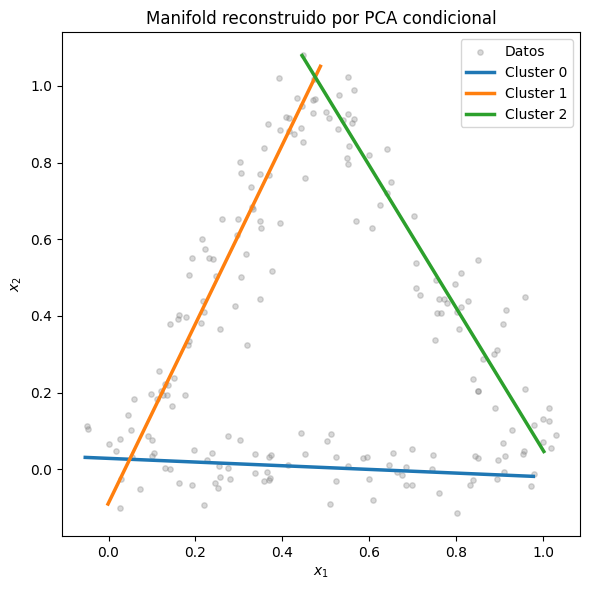

In [52]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(X[:, 0], X[:, 1], s=15, alpha=0.3, color='gray', label='Datos')

for j, pca_j in enumerate(pcas):
    mask = labels_em == j
    proj = pca_j.transform(X[mask], k=1)
    u_range = np.linspace(proj.min(), proj.max(), 200).reshape(-1, 1)
    line = pca_j.inverse_transform(u_range)
    ax.plot(line[:, 0], line[:, 1], color=colors[j], linewidth=2.5, label=f'Cluster {j}')

ax.set_title('Manifold reconstruido por PCA condicional')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend()
plt.tight_layout()
plt.show()

### Comparación con el manifold real y error de reconstrucción

<>:40: SyntaxWarning: invalid escape sequence '\|'
<>:40: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_82116/4117226023.py:40: SyntaxWarning: invalid escape sequence '\|'
  ax.set_xlabel('Error de reconstrucción ($\|\|x - \hat{x}\|\|$)')


Cluster 0: error medio = 0.0379,  error máx = 0.1112
Cluster 1: error medio = 0.0337,  error máx = 0.1299
Cluster 2: error medio = 0.0387,  error máx = 0.1519
Global:    error medio = 0.0366,  error máx = 0.1519


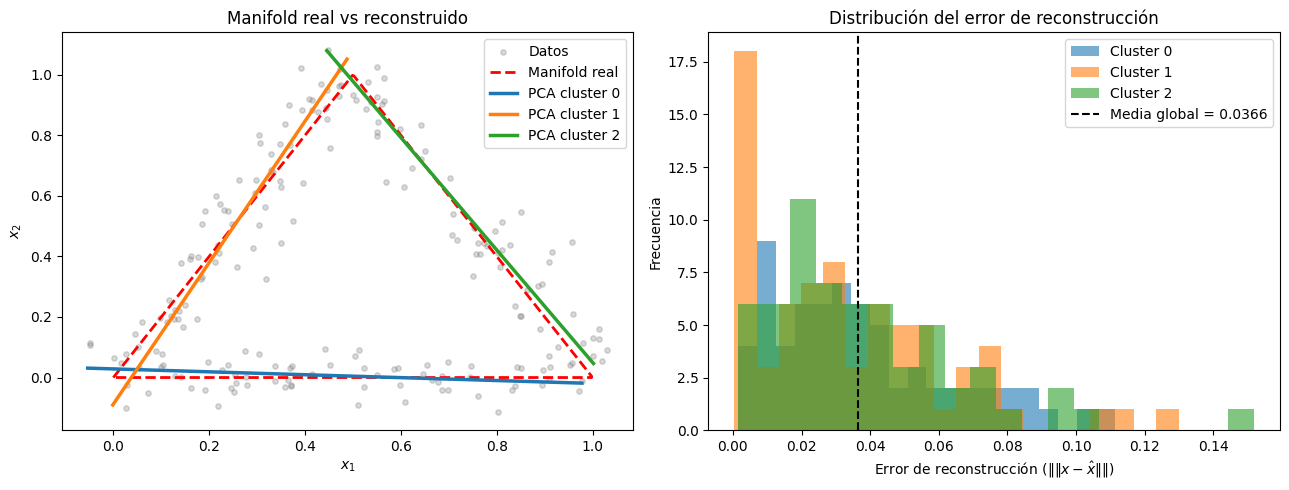

In [53]:
# Error de reconstrucción por punto: ||x_i - PCA^{-1}(PCA(x_i))||
errors = np.zeros(len(X))
X_rec = np.zeros_like(X)

for j, pca_j in enumerate(pcas):
    mask = labels_em == j
    proj = pca_j.transform(X[mask], k=1)
    X_rec[mask] = pca_j.inverse_transform(proj)
    errors[mask] = np.linalg.norm(X[mask] - X_rec[mask], axis=1)

for j in range(em.k):
    mask = labels_em == j
    print(f'Cluster {j}: error medio = {errors[mask].mean():.4f},  error máx = {errors[mask].max():.4f}')
print(f'Global:    error medio = {errors.mean():.4f},  error máx = {errors.max():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Izquierda: manifold real (rojo) vs reconstruido (colores por cluster)
ax = axes[0]
ax.scatter(X[:, 0], X[:, 1], s=15, alpha=0.3, color='gray', label='Datos')
ax.plot(M[:, 0], M[:, 1], color='red', linewidth=2, linestyle='--', label='Manifold real')
for j, pca_j in enumerate(pcas):
    mask = labels_em == j
    proj = pca_j.transform(X[mask], k=1)
    u_range = np.linspace(proj.min(), proj.max(), 200).reshape(-1, 1)
    line = pca_j.inverse_transform(u_range)
    ax.plot(line[:, 0], line[:, 1], color=colors[j], linewidth=2.5, label=f'PCA cluster {j}')
ax.set_title('Manifold real vs reconstruido')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend()

# Derecha: histograma del error de reconstrucción por cluster
ax = axes[1]
for j in range(em.k):
    mask = labels_em == j
    ax.hist(errors[mask], bins=20, alpha=0.6, color=colors[j], label=f'Cluster {j}')
ax.axvline(errors.mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Media global = {errors.mean():.4f}')
ax.set_xlabel('Error de reconstrucción ($\|\|x - \hat{x}\|\|$)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del error de reconstrucción')
ax.legend()

plt.tight_layout()
plt.show()